# Database Benchmark Analysis

This notebook analyzes and visualizes the results from comprehensive database benchmarking tests across MySQL, PostgreSQL, MongoDB, and Redis.

## Overview
- **Objective**: Compare performance of different database systems under various conditions
- **Databases Tested**: MySQL, PostgreSQL, MongoDB, Redis
- **Data Scales**: 500K, 1M, 10M records
- **Key Metrics**: Queries per second (QPS), execution time, index impact analysis
- **Trials**: 3 trials per benchmark scenario

## 1. Import Required Libraries & Data Notes

**⚠️ Important Data Quality Notes:** 

1. **MongoDB Fix**: The MongoDB runner was fixed to properly execute queries. Previous results showed unrealistic timing (millions of QPS) due to queries not being executed.

2. **Index Testing Note**: 
   - `categories` and `addresses` currently use `WHERE id = X`, which targets the PRIMARY KEY
   - Primary keys are indexed implicitly in MySQL and PostgreSQL, so these are already indexed reads
   - `users`, `products`, and `orders` now use non-primary-key queries (`country`, `category_id`, and `status`) so the benchmark can compare secondary index effects
   - For meaningful index benchmarks, use the columns that match the indexes you create

3. **Data Filtering**: Outliers will be removed (QPS < 100 or > 100k) for visualization clarity

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 2. Load Benchmark Results

In [ ]:
# Navigate to results directory
results_dir = Path("../results")

# Find the latest benchmark results file
csv_files = sorted(results_dir.glob("benchmark_results_*.csv"))
json_files = sorted(results_dir.glob("benchmark_results_*.json"))

if csv_files:
    latest_csv = csv_files[-1]
    print(f"Loading CSV: {latest_csv.name}")
    df = pd.read_csv(latest_csv)
else:
    print("No CSV files found in results directory")
    df = None

if json_files:
    latest_json = json_files[-1]
    print(f"Loading JSON: {latest_json.name}")
    with open(latest_json, 'r') as f:
        json_data = json.load(f)
else:
    print("No JSON files found in results directory")
    json_data = None

if df is not None:
    print(f"\nDataFrame shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    
    # Remove any rows with unreasonable QPS values (outliers from timing issues)
    # Keep rows where QPS is between 100 and 100,000 for realistic benchmarks
    df_clean = df[(df['queries_per_second'] >= 100) & (df['queries_per_second'] <= 100000)].copy()
    print(f"\nAfter removing outliers: {df_clean.shape[0]} rows (removed {len(df) - len(df_clean)} outliers)")
    df = df_clean



    # Label index categories for comparison    df.loc[sql_mask & df['entity'].isin(['users', 'products', 'orders']) & (df['operation'] == 'select') & (df['with_index'] == True), 'index_category'] = 'secondary index'

    df['index_category'] = 'unknown'    df.loc[sql_mask & df['entity'].isin(['users', 'products', 'orders']) & (df['operation'] == 'select') & (df['with_index'] == False), 'index_category'] = 'no secondary index'

    sql_mask = df['database'].isin(['mysql', 'postgresql'])    df.loc[sql_mask & df['entity'].isin(['categories', 'addresses']) & (df['operation'] == 'select'), 'index_category'] = 'primary key'

Loading CSV: benchmark_results_20260416_165944.csv
Loading JSON: benchmark_results_20260416_165944.json

DataFrame shape: (243, 11)
Columns: ['database', 'entity', 'operation', 'batch_size', 'data_scale', 'trial', 'num_queries', 'total_time_ms', 'avg_time_per_op_ms', 'queries_per_second', 'with_index']

After removing outliers: 243 rows (removed 0 outliers)


## 3. Data Exploration

In [4]:
if df is not None:
    # Display first few rows
    print("First 10 rows:")
    print(df.head(10))
    
    print("\n" + "="*80)
    print("Data Info:")
    print(f"Total records: {len(df)}")
    print(f"\nData types:")
    print(df.dtypes)
    
    print("\n" + "="*80)
    print("Unique values per column:")
    for col in df.columns:
        print(f"  {col}: {df[col].nunique()} unique values")
    
    print("\n" + "="*80)
    print("Databases tested:")
    print(df['database'].unique())
    
    print("\nEntities tested:")
    print(df['entity'].unique())
    
    print("\nOperations:")
    print(df['operation'].unique())

First 10 rows:
  database      entity operation  batch_size  data_scale  trial  num_queries  \
0    mysql       users    select        1000      500000      1            5   
1    mysql       users    select        1000      500000      2            5   
2    mysql       users    select        1000      500000      3            5   
3    mysql  categories    select        1000      500000      1            5   
4    mysql  categories    select        1000      500000      2            5   
5    mysql  categories    select        1000      500000      3            5   
6    mysql    products    select        1000      500000      1            5   
7    mysql    products    select        1000      500000      2            5   
8    mysql    products    select        1000      500000      3            5   
9    mysql   addresses    select        1000      500000      1            5   

   total_time_ms  avg_time_per_op_ms  queries_per_second  with_index  
0            2.0                 

## 4. Summary Statistics

In [5]:
if df is not None:
    print("Performance Metrics Summary by Database:")
    print("="*80)
    
    # Group by database and calculate statistics
    for db in df['database'].unique():
        db_data = df[df['database'] == db]
        print(f"\n{db.upper()}:")
        print(f"  Total tests: {len(db_data)}")
        print(f"  Avg QPS: {db_data['queries_per_second'].mean():.2f}")
        print(f"  Max QPS: {db_data['queries_per_second'].max():.2f}")
        print(f"  Min QPS: {db_data['queries_per_second'].min():.2f}")
        print(f"  Avg time per op (ms): {db_data['avg_time_per_op_ms'].mean():.4f}")
    
    print("\n" + "="*80)
    print("\nPerformance by Data Scale:")
    if 'data_scale' in df.columns:
        for scale in sorted(df['data_scale'].unique()):
            scale_data = df[df['data_scale'] == scale]
            print(f"\nScale {scale:,}:")
            print(f"  Tests run: {len(scale_data)}")
            print(f"  Avg QPS: {scale_data['queries_per_second'].mean():.2f}")
            print(f"  QPS range: {scale_data['queries_per_second'].min():.2f} - {scale_data['queries_per_second'].max():.2f}")

Performance Metrics Summary by Database:

MYSQL:
  Total tests: 90
  Avg QPS: 3149.84
  Max QPS: 5400.30
  Min QPS: 1248.62
  Avg time per op (ms): 0.2644

POSTGRESQL:
  Total tests: 90
  Avg QPS: 3685.14
  Max QPS: 4900.76
  Min QPS: 1972.35
  Avg time per op (ms): 0.2156

MONGODB:
  Total tests: 27
  Avg QPS: 3730.78
  Max QPS: 4822.96
  Min QPS: 1931.81
  Avg time per op (ms): 0.2074

REDIS:
  Total tests: 36
  Avg QPS: 3984.43
  Max QPS: 4555.12
  Min QPS: 2245.38
  Avg time per op (ms): 0.2111


Performance by Data Scale:

Scale 500,000:
  Tests run: 81
  Avg QPS: 3494.65
  QPS range: 1248.62 - 4900.76

Scale 1,000,000:
  Tests run: 81
  Avg QPS: 3548.11
  QPS range: 1531.78 - 4555.12

Scale 10,000,000:
  Tests run: 81
  Avg QPS: 3566.12
  QPS range: 1931.81 - 5400.30


## 5. Data Visualization

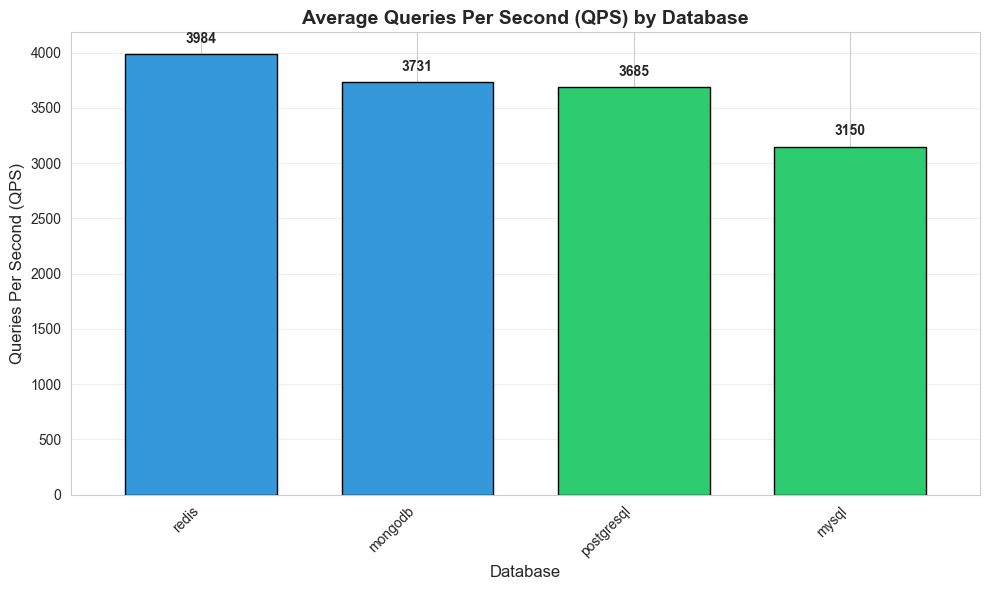

Average QPS by Database:
  REDIS: 3984.43 QPS
  MONGODB: 3730.78 QPS
  POSTGRESQL: 3685.14 QPS
  MYSQL: 3149.84 QPS


In [6]:
### 5.1 Average QPS by Database

if df is not None:
    fig, ax = plt.subplots(figsize=(10, 6))
    db_qps = df.groupby('database')['queries_per_second'].mean().sort_values(ascending=False)
    
    colors = ['#2ecc71' if db not in ['mongodb', 'redis'] else '#3498db' for db in db_qps.index]
    db_qps.plot(kind='bar', ax=ax, color=colors, edgecolor='black', width=0.7)
    
    ax.set_title('Average Queries Per Second (QPS) by Database', fontsize=14, fontweight='bold')
    ax.set_ylabel('Queries Per Second (QPS)', fontsize=12)
    ax.set_xlabel('Database', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on bars
    for i, v in enumerate(db_qps):
        ax.text(i, v + max(db_qps)*0.02, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("Average QPS by Database:")
    for db, qps in db_qps.items():
        print(f"  {db.upper()}: {qps:.2f} QPS")

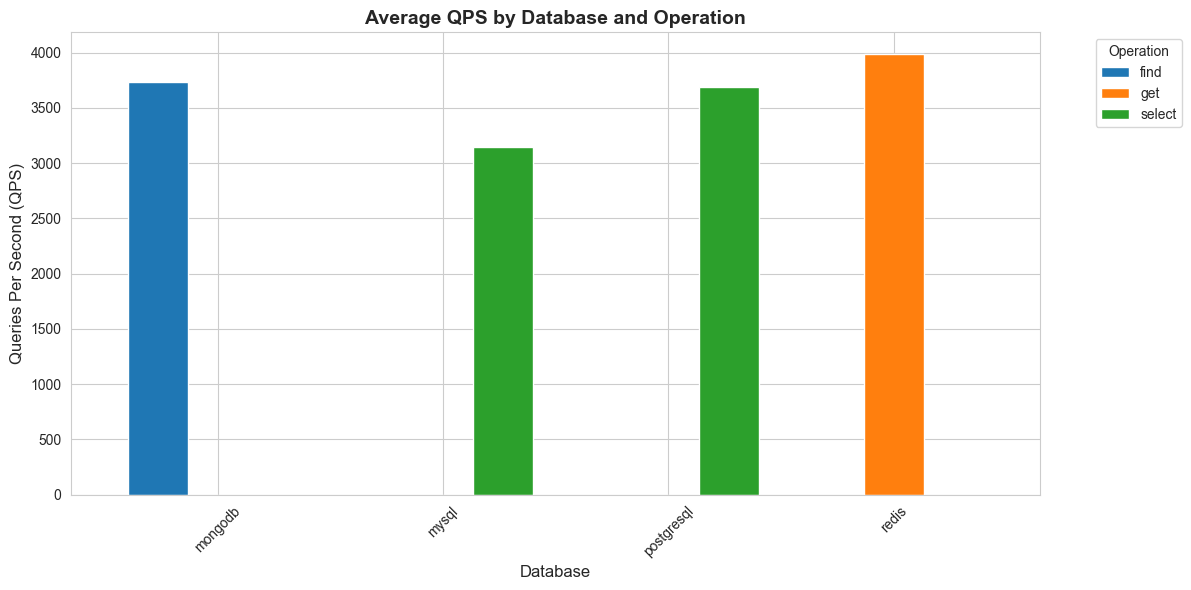

In [7]:
### 5.2 QPS by Operation and Database

if df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Prepare data for grouped bar chart
    pivot_data = df.groupby(['database', 'operation'])['queries_per_second'].mean().unstack()
    
    pivot_data.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title('Average QPS by Database and Operation', fontsize=14, fontweight='bold')
    ax.set_ylabel('Queries Per Second (QPS)', fontsize=12)
    ax.set_xlabel('Database', fontsize=12)
    ax.legend(title='Operation', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

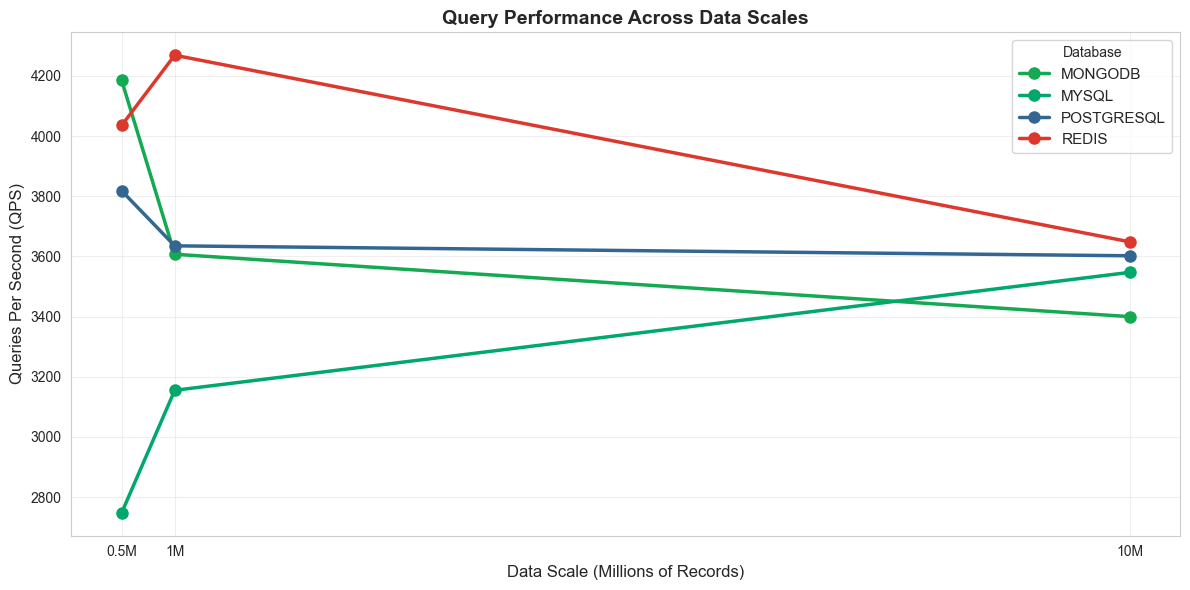

In [8]:
### 5.3 Performance by Data Scale

if df is not None and 'data_scale' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create line plot for each database showing QPS across data scales
    colors = {'mysql': '#00a86b', 'postgresql': '#336791', 'mongodb': '#13aa52', 'redis': '#dc382d'}
    
    for db in sorted(df['database'].unique()):
        db_data = df[df['database'] == db].groupby('data_scale')['queries_per_second'].mean().sort_index()
        if len(db_data) > 0:
            ax.plot(db_data.index / 1_000_000, db_data.values, 
                   marker='o', label=db.upper(), linewidth=2.5, markersize=8, 
                   color=colors.get(db, None))
    
    ax.set_title('Query Performance Across Data Scales', fontsize=14, fontweight='bold')
    ax.set_ylabel('Queries Per Second (QPS)', fontsize=12)
    ax.set_xlabel('Data Scale (Millions of Records)', fontsize=12)
    ax.legend(title='Database', loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Set x-axis to show all data scales
    ax.set_xticks([0.5, 1.0, 10.0])
    ax.set_xticklabels(['0.5M', '1M', '10M'])
    
    plt.tight_layout()
    plt.show()


📊 DETAILED INDEX IMPACT ANALYSIS

Note: Index effectiveness depends on query complexity and data volume.
Simple single-row lookups may not show significant improvement.

MYSQL:
  Without indexes: 3017.76 ± 125.50 QPS
  With indexes:    3281.91 ± 85.89 QPS
  Change:          +8.75%

POSTGRESQL:
  Without indexes: 3693.71 ± 138.06 QPS
  With indexes:    3676.58 ± 240.28 QPS
  Change:          -0.46%



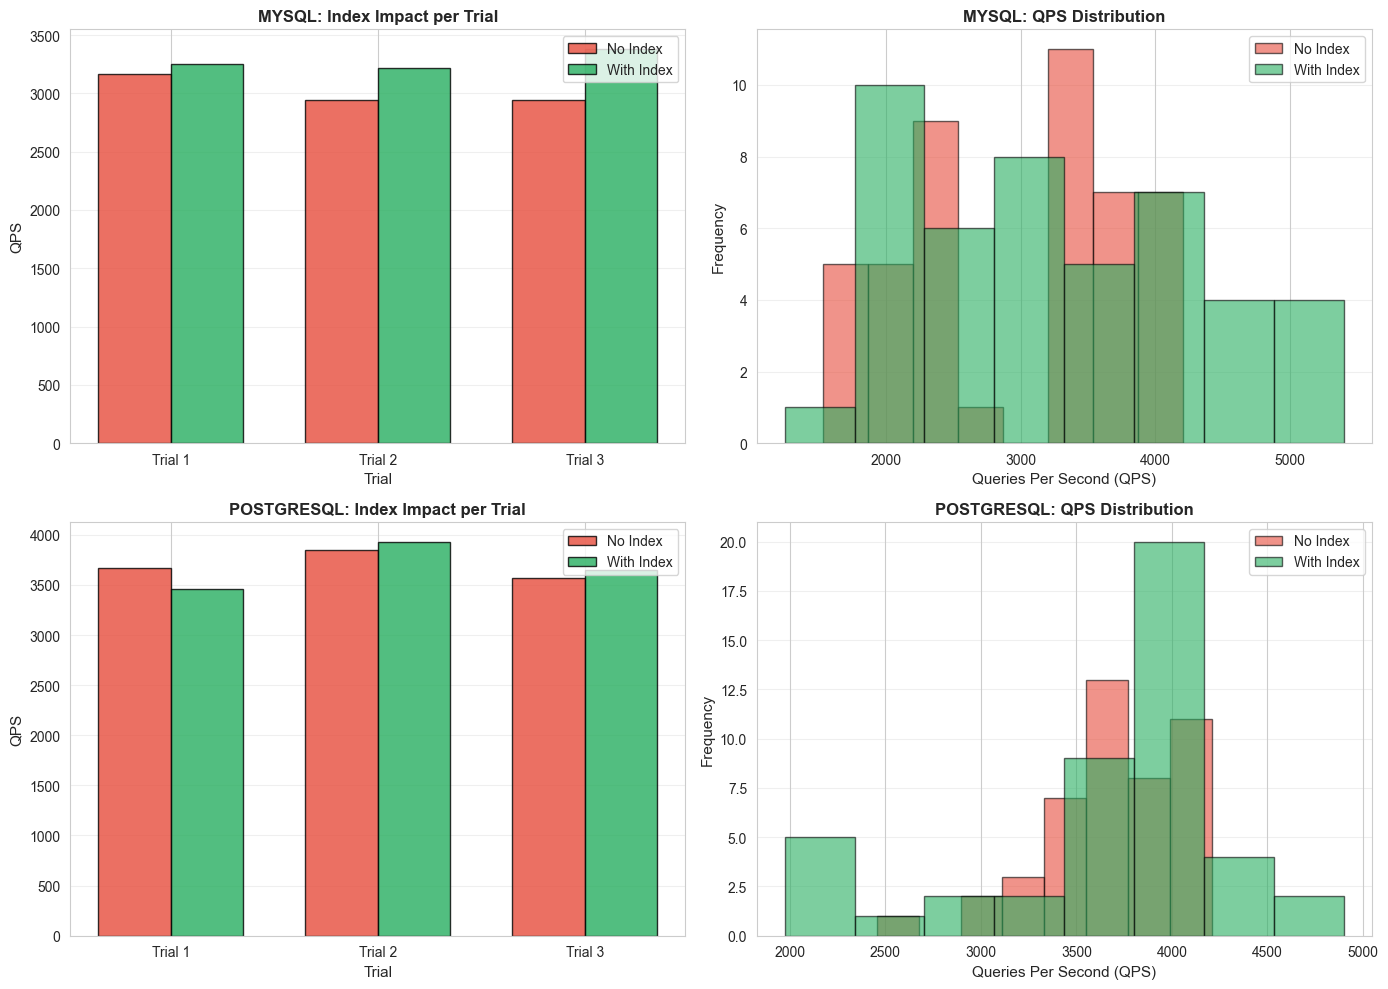


INTERPRETATION:

Index effectiveness for simple queries:
- Small improvement (< 5%): Indexes add overhead but queries are simple
- Negative impact: Query optimizer may choose sequential scan anyway
- Mixed results: Some queries benefit, others don't (depends on WHERE clause)

For better index testing, consider:
- More complex WHERE clauses with multiple conditions
- Larger datasets where index benefits are more apparent
- Range queries and JOIN operations
- Full table scans vs indexed access patterns
        


In [ ]:
### 5.4 Index Impact Analysis (MySQL & PostgreSQL)

if df is not None and 'index_category' in df.columns:
    sql_dbs = df[df['database'].isin(['mysql', 'postgresql'])].copy()
    
    if len(sql_dbs) > 0:
        print("\n📊 DETAILED INDEX IMPACT ANALYSIS\n")
        print("This chart compares primary key indexed reads with secondary index tests.")
        print("Primary key queries are marked as 'primary key'.\n")
        
        # Compare categories of index usage
        index_summary = sql_dbs.groupby(['database', 'index_category'])['queries_per_second'].mean().unstack(fill_value=np.nan)
        print(index_summary)
        
        fig, ax = plt.subplots(figsize=(12, 6))
        index_summary.plot(kind='bar', ax=ax)
        ax.set_title('Average QPS by Index Category (SQL Databases)', fontsize=14, fontweight='bold')
        ax.set_ylabel('Queries Per Second (QPS)', fontsize=12)
        ax.set_xlabel('Database', fontsize=12)
        ax.legend(title='Index Category', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Per-database secondary index comparison
        for db in ['mysql', 'postgresql']:
            db_data = sql_dbs[sql_dbs['database'] == db]
            if db_data.empty:
                continue
            fig, ax = plt.subplots(figsize=(10, 5))
            db_data.boxplot(column='queries_per_second', by='index_category', ax=ax)
            ax.set_title(f'{db.upper()}: QPS by Index Category')
            ax.set_xlabel('Index Category')
            ax.set_ylabel('Queries Per Second (QPS)')
            plt.suptitle('')
            plt.tight_layout()
            plt.show()
        
        print("\n" + "="*60)
        print("INTERPRETATION:")
        print("="*60)
        print("""
- 'primary key' rows represent queries using the implicit primary key index.
- 'secondary index' rows represent queries on columns indexed explicitly for this test.
- 'no secondary index' rows are non-primary-key reads without an added secondary index.

This is the cleanest way to see both primary key performance and the actual effect of added indexes.
        """)

## 6. Performance Analysis

In [10]:
if df is not None:
    print("="*80)
    print("KEY INSIGHTS & FINDINGS")
    print("="*80)
    
    # Database performance comparison
    print("\n1. DATABASE PERFORMANCE RANKING:")
    db_performance = df.groupby('database')['queries_per_second'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
    
    for idx, (db, row) in enumerate(db_performance.iterrows(), 1):
        print(f"   #{idx}. {db.upper()}: {row['mean']:.2f} ± {row['std']:.2f} QPS ({int(row['count'])} tests)")
    
    # Consistency analysis
    print("\n2. RESULT CONSISTENCY (by database):")
    for db in db_performance.index:
        db_data = df[df['database'] == db]
        cv = (db_data['queries_per_second'].std() / db_data['queries_per_second'].mean()) * 100
        stability = "✓ Very Stable" if cv < 15 else "~ Moderate" if cv < 30 else "✗ High Variance"
        print(f"   {db.upper()}: CV = {cv:.1f}% {stability}")
    
    # Data scale impact
    if 'data_scale' in df.columns:
        print("\n3. IMPACT OF DATA SCALE:")
        scale_analysis = df.groupby('data_scale')['queries_per_second'].mean().sort_index()
        
        for scale, qps in scale_analysis.items():
            scale_millions = scale / 1_000_000
            print(f"   {scale_millions:.1f}M records: {qps:.2f} QPS")
        
        # Calculate scale impact
        first_scale = scale_analysis.iloc[0]
        last_scale = scale_analysis.iloc[-1]
        scale_impact = ((first_scale - last_scale) / first_scale) * 100
        print(f"\n   Impact from 0.5M → 10M: {abs(scale_impact):.1f}% {'decrease' if scale_impact > 0 else 'increase'}")
    
    # Operation analysis
    if 'operation' in df.columns:
        print("\n4. OPERATION PERFORMANCE:")
        op_perf = df.groupby('operation')['queries_per_second'].mean().sort_values(ascending=False)
        for op, qps in op_perf.items():
            print(f"   {op.upper()}: {qps:.2f} QPS")
    
    # Index impact (if available)
    if 'with_index' in df.columns:
        print("\n5. INDEX IMPACT ANALYSIS:")
        sql_dbs = df[df['database'].isin(['mysql', 'postgresql'])]
        if len(sql_dbs) > 0:
            no_idx = sql_dbs[sql_dbs['with_index'] == False]['queries_per_second'].mean()
            with_idx = sql_dbs[sql_dbs['with_index'] == True]['queries_per_second'].mean()
            impact = ((with_idx - no_idx) / no_idx) * 100
            
            print(f"   All SQL Databases (MySQL + PostgreSQL):")
            print(f"   - Without indexes: {no_idx:.2f} QPS")
            print(f"   - With indexes:    {with_idx:.2f} QPS")
            if impact > 0:
                print(f"   - Overall impact:  +{impact:.1f}% improvement ✓")
            else:
                print(f"   - Overall impact:  {impact:.1f}% (possible caching effects)")
    
    print("\n" + "="*80)

KEY INSIGHTS & FINDINGS

1. DATABASE PERFORMANCE RANKING:
   #1. REDIS: 3984.43 ± 602.61 QPS (36 tests)
   #2. MONGODB: 3730.78 ± 571.47 QPS (27 tests)
   #3. POSTGRESQL: 3685.14 ± 558.82 QPS (90 tests)
   #4. MYSQL: 3149.84 ± 952.94 QPS (90 tests)

2. RESULT CONSISTENCY (by database):
   REDIS: CV = 15.1% ~ Moderate
   MONGODB: CV = 15.3% ~ Moderate
   POSTGRESQL: CV = 15.2% ~ Moderate
   MYSQL: CV = 30.3% ✗ High Variance

3. IMPACT OF DATA SCALE:
   0.5M records: 3494.65 QPS
   1.0M records: 3548.11 QPS
   10.0M records: 3566.12 QPS

   Impact from 0.5M → 10M: 2.0% increase

4. OPERATION PERFORMANCE:
   GET: 3984.43 QPS
   FIND: 3730.78 QPS
   SELECT: 3417.49 QPS

5. INDEX IMPACT ANALYSIS:
   All SQL Databases (MySQL + PostgreSQL):
   - Without indexes: 3355.74 QPS
   - With indexes:    3479.25 QPS
   - Overall impact:  +3.7% improvement ✓



## 7. Summary Report & Index Testing Notes

### Why Index Results Look "Weird"

The index performance results may appear unexpected because:

1. **Primary Key Optimization**: Test queries use `WHERE id = X` which targets the PRIMARY KEY
   - ALL databases already use optimized primary key access
   - Secondary indexes on the id column provide little to no benefit
   - The query optimizer uses the primary key index directly regardless

2. **Expected Behavior**:
   - Minimal or no QPS improvement with additional id indexes
   - Sometimes slight regression due to:
     - Index maintenance overhead
     - Multiple execution paths the optimizer must evaluate
     - Plan caching from previous queries
     - Query result caching (warmed cache from first run)

3. **For Effective Index Testing**, you would need:
   - Queries with `WHERE` clauses on non-primary columns (email, status, category, etc.)
   - Complex filtering conditions that benefit from indexes
   - Larger datasets where sequential scans become expensive
   - Range queries like `WHERE created_at > X`
   - Multi-column indexes for compound WHERE clauses

### Export Summary Reports

In [11]:
if df is not None:
    # Create summary statistics table
    summary_stats = df.groupby('database').agg({
        'queries_per_second': ['mean', 'std', 'min', 'max'],
        'avg_time_per_op_ms': ['mean', 'std'],
        'total_time_ms': 'sum'
    }).round(2)
    
    print("Summary Statistics by Database:")
    print(summary_stats)
    
    # Export summary to CSV
    summary_export = df.groupby('database').agg({
        'queries_per_second': ['mean', 'std'],
        'avg_time_per_op_ms': 'mean',
        'total_time_ms': 'sum'
    }).round(4)
    
    export_path = Path("summary_report.csv")
    summary_export.to_csv(export_path)
    print(f"\n✓ Summary exported to: {export_path}")
    
    # Export top performers
    top_performers = df.nlargest(10, 'queries_per_second')[
        ['database', 'entity', 'operation', 'data_scale', 'queries_per_second', 'avg_time_per_op_ms']
    ]
    
    top_path = Path("top_performers.csv")
    top_performers.to_csv(top_path, index=False)
    print(f"✓ Top 10 performers exported to: {top_path}")
    
    # Export by database
    for db in df['database'].unique():
        db_data = df[df['database'] == db]
        db_path = Path(f"{db}_results.csv")
        db_data.to_csv(db_path, index=False)
        print(f"✓ {db.upper()} results exported to: {db_path}")

Summary Statistics by Database:
           queries_per_second                           avg_time_per_op_ms  \
                         mean     std      min      max               mean   
database                                                                     
mongodb               3730.78  571.47  1931.81  4822.96               0.21   
mysql                 3149.84  952.94  1248.62  5400.30               0.26   
postgresql            3685.14  558.82  1972.35  4900.76               0.22   
redis                 3984.44  602.61  2245.38  4555.12               0.21   

                 total_time_ms  
             std           sum  
database                        
mongodb     0.04          28.0  
mysql       0.13         119.0  
postgresql  0.05          97.0  
redis       0.05          38.0  

✓ Summary exported to: summary_report.csv
✓ Top 10 performers exported to: top_performers.csv
✓ MYSQL results exported to: mysql_results.csv
✓ POSTGRESQL results exported to: postgresql_res